In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import yfinance as yf

In [101]:
df = yf.download(tickers='SPY',
                auto_adjust=False,
                actions=True,
                start='1993-01-01',
                end='2016-01-01',
                interval='1mo')

df.droplevel(level=1, axis=1)

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,,
1993-01-01,24.241404,0.0,43.937500,0.000,43.968750,43.750000,43.968750,0.0,1003200
1993-02-01,24.500023,0.0,44.406250,0.000,45.125000,42.812500,43.968750,0.0,5417600
1993-03-01,24.931051,0.0,45.187500,0.213,45.843750,44.218750,44.562500,0.0,3019200
1993-04-01,24.407873,0.0,44.031250,0.000,45.250000,43.281250,45.250000,0.0,2697200
1993-05-01,25.066139,0.0,45.218750,0.000,45.656250,43.843750,44.093750,0.0,1808000
...,...,...,...,...,...,...,...,...,...
2015-08-01,165.680420,0.0,197.669998,0.000,211.309998,182.399994,210.460007,0.0,3734926900
2015-09-01,160.617874,0.0,191.630005,1.033,202.889999,186.929993,193.119995,0.0,3279512900
2015-10-01,175.186081,0.0,207.929993,0.000,209.440002,189.119995,192.080002,0.0,2536184400


In [102]:
df['factor'] = df['Adj Close'] / df['Close'] 

df

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume,factor
Ticker,SPY,SPY,SPY,SPY,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,,,,,
1993-01-01,24.241404,0.0,43.937500,0.000,43.968750,43.750000,43.968750,0.0,1003200,0.551725
1993-02-01,24.500023,0.0,44.406250,0.000,45.125000,42.812500,43.968750,0.0,5417600,0.551725
1993-03-01,24.931051,0.0,45.187500,0.213,45.843750,44.218750,44.562500,0.0,3019200,0.551725
1993-04-01,24.407873,0.0,44.031250,0.000,45.250000,43.281250,45.250000,0.0,2697200,0.554331
1993-05-01,25.066139,0.0,45.218750,0.000,45.656250,43.843750,44.093750,0.0,1808000,0.554331
...,...,...,...,...,...,...,...,...,...,...
2015-08-01,165.680420,0.0,197.669998,0.000,211.309998,182.399994,210.460007,0.0,3734926900,0.838167
2015-09-01,160.617874,0.0,191.630005,1.033,202.889999,186.929993,193.119995,0.0,3279512900,0.838167


In [103]:
#if actions['Dividends'] > 0:
#    df1['div_back_adj'] = df1['Close'] * (1 - (actions['Dividends']/df['Close'].shift(1)))
#    df1['div_forw_adj'] = df1['Close'] * (df['Close'].shift(1)/(df['Close'].shift(1) - actions['Dividends']))

In [104]:
df['return'] = (df['Close'] / df['Close'].shift(1))-1
df['adj return'] = (df['Adj Close'] / df['Adj Close'].shift(1))-1

df.droplevel(level=1, axis=1)

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume,factor,return,adj return
Date,,,,,,,,,,,,
1993-01-01,24.241404,0.0,43.937500,0.000,43.968750,43.750000,43.968750,0.0,1003200,0.551725,NaN,NaN
1993-02-01,24.500023,0.0,44.406250,0.000,45.125000,42.812500,43.968750,0.0,5417600,0.551725,0.010669,0.010668
1993-03-01,24.931051,0.0,45.187500,0.213,45.843750,44.218750,44.562500,0.0,3019200,0.551725,0.017593,0.017593
1993-04-01,24.407873,0.0,44.031250,0.000,45.250000,43.281250,45.250000,0.0,2697200,0.554331,-0.025588,-0.020985
1993-05-01,25.066139,0.0,45.218750,0.000,45.656250,43.843750,44.093750,0.0,1808000,0.554331,0.026969,0.026969
...,...,...,...,...,...,...,...,...,...,...,...,...
2015-08-01,165.680420,0.0,197.669998,0.000,211.309998,182.399994,210.460007,0.0,3734926900,0.838167,-0.060950,-0.060950
2015-09-01,160.617874,0.0,191.630005,1.033,202.889999,186.929993,193.119995,0.0,3279512900,0.838167,-0.030556,-0.030556
2015-10-01,175.186081,0.0,207.929993,0.000,209.440002,189.119995,192.080002,0.0,2536184400,0.842524,0.085060,0.090701


<Axes: ylabel='Frequency'>

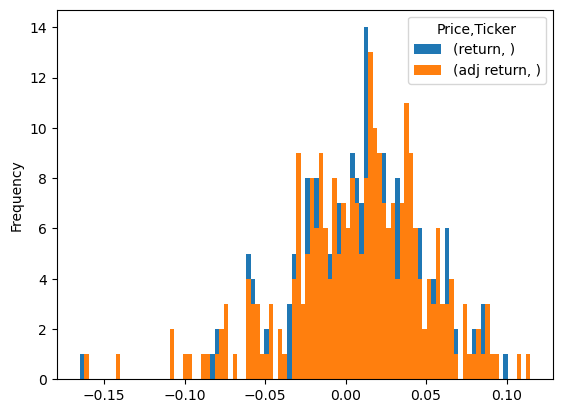

In [105]:
df[['return', 'adj return']].plot(kind='hist', bins=100)

<Axes: xlabel='Date'>

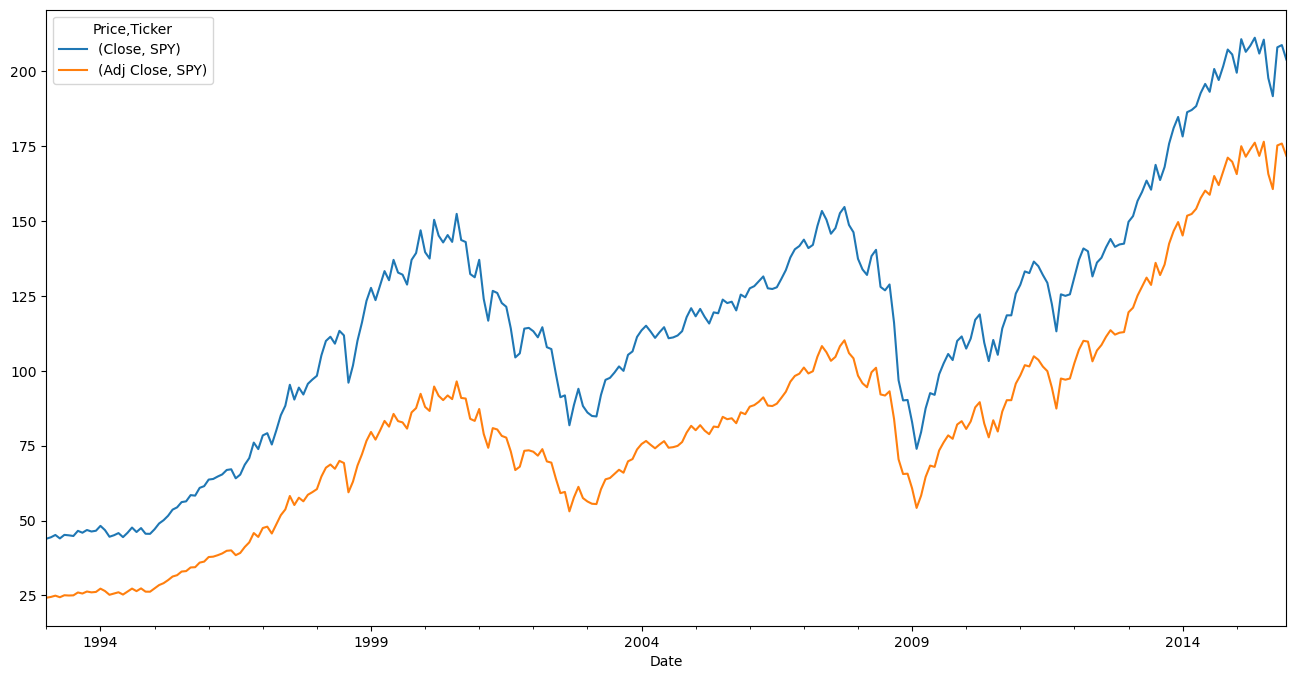

In [106]:
df[['Close', 'Adj Close']].plot(figsize=(16, 8))

<Axes: xlabel='Date'>

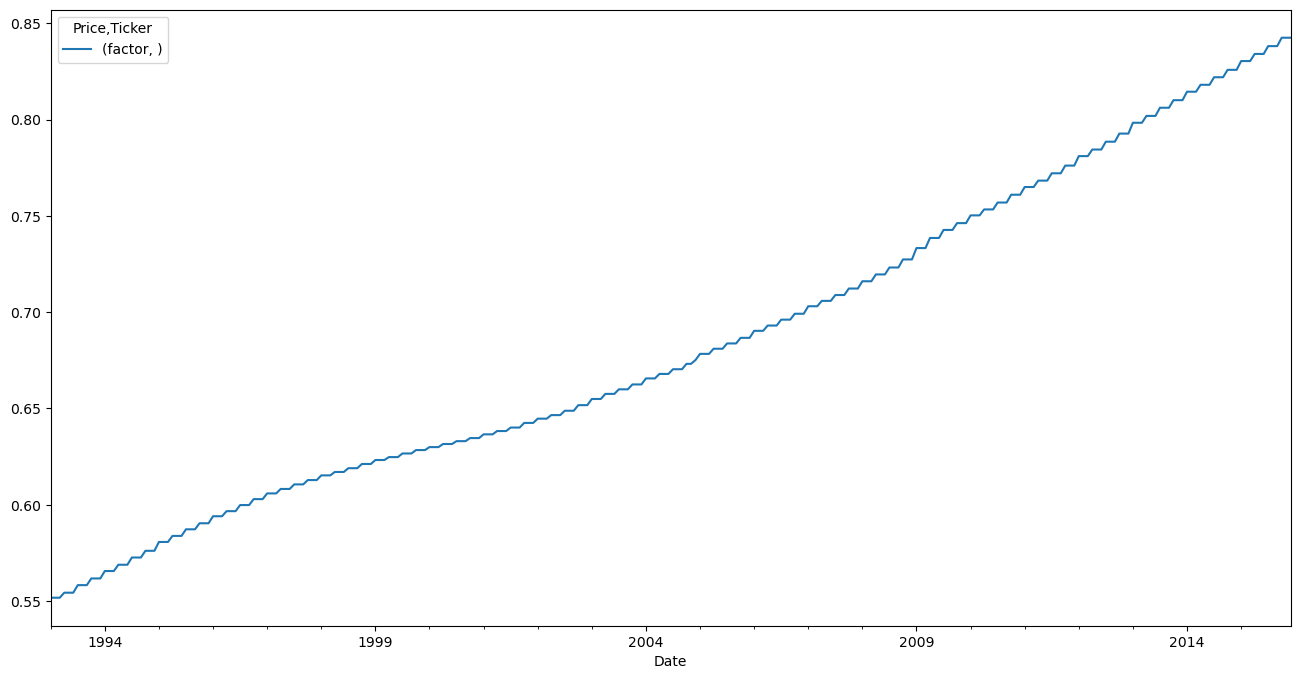

In [107]:
df[['factor']].plot(figsize=(16, 8))

In [111]:
curr = yf.download(tickers=['USD=X',
                            'EURUSD=X',	
                            'GBPUSD=X',	
                            'CNYUSD=X',	
                            'AEDUSD=X',	
                            'TRYUSD=X',
                            'RUBUSD=X',
                            'SEKUSD=X',
                            'NOKUSD=X',
                            'DKKUSD=X',
                            'ISKUSD=X'],
                start='2020-01-01')


curr.droplevel(level=1, axis=1)

[*********************100%***********************]  11 of 11 completed


Price,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,...,Volume,Volume,Volume,Volume,Volume,Volume,Volume,Volume,Volume,Volume
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,0.272316,0.143631,0.150089,1.122083,1.326260,0.008277,0.119659,0.016122,0.109042,0.168129,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
2020-01-02,0.272316,0.143633,0.150177,1.122083,1.325030,0.008282,0.114025,0.016173,0.107073,0.168172,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
2020-01-03,0.272316,0.143608,0.149495,1.117144,1.315270,0.008168,0.113754,0.016209,0.106822,0.167906,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
2020-01-06,0.272290,0.143585,0.149359,1.116196,1.308010,0.008171,0.113196,0.016121,0.106274,0.167561,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
2020-01-07,0.272316,0.143379,0.149813,1.119799,1.317003,0.008174,0.113746,0.016188,0.106343,0.167532,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,0.272368,0.144760,0.157868,1.179384,1.349692,0.008159,0.104606,0.013192,0.110378,0.022807,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
2026-02-25,0.272368,0.145283,0.157612,1.177523,1.349746,0.008191,0.104613,0.013064,0.110572,0.022803,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
2026-02-26,0.272368,0.145577,0.158149,1.181516,1.355803,0.008262,0.104803,0.012947,0.110927,0.022797,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN


In [119]:
import yfinance as yf

tickers = ['USD=X',
                            'EURUSD=X',	
                            'GBPUSD=X',	
                            'CNYUSD=X',	
                            'AEDUSD=X',	
                            'TRYUSD=X',
                            'RUBUSD=X',
                            'SEKUSD=X',
                            'NOKUSD=X',
                            'DKKUSD=X',
                            'ISKUSD=X'] # Vos devises
data = yf.download(tickers, period="max")

# On ne garde que la clôture ('Close')
curr = data['Close']

# Si les colonnes sont encore des tickers complets, on les renomme
# Cela transforme "EURUSD=X" en "EUR"
curr.columns = [col.replace('USD=X', '') for col in df_close.columns]

curr.head()


USD=X: Period 'max' is invalid, must be one of: 1d, 5d
[*********************100%***********************]  11 of 11 completed

1 Failed download:
['USD=X']: Period 'max' is invalid, must be one of: 1d, 5d


,AED,CNY,DKK,EUR,GBP,ISK,NOK,RUB,SEK,TRY,
Date,,,,,,,,,,,
2001-06-25,NaN,0.120820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-06-26,NaN,0.120820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-02,NaN,0.120817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-09,NaN,0.120821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-11,NaN,0.120818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Date'>

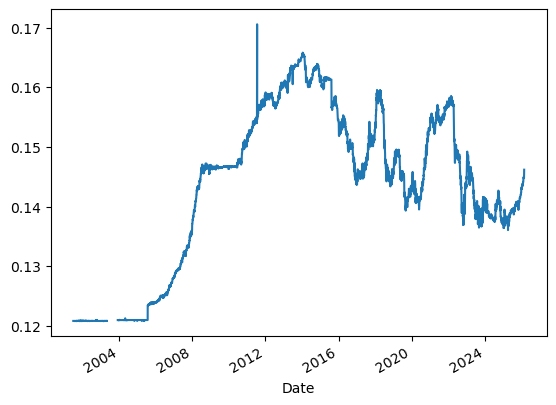

In [121]:
df_close['CNY'].plot()